# 📊 Metriky klasifikačních modelů – Cvičení 1: Diagnostika bederní páteře
### Dataset: `lumbar_df_normalized.csv` (310 pacientů, 6 normalizovaných parametrů páteře) | Coders Lab (09/2026)

> **Zadání cvičení (Classification metrics - exercise 1):**
> 1. Stáhněte přiložený dataset (`lumbar_df_normalized.csv`) a notebook (`Classification_metrics_exercise_1.ipynb`).
> 2. Spusťte všechny buňky s kódem ve výchozím nastavení (dělení 75/25, `random_state=42`, `stratify=y`, $k=5$).
> 3. Vygenerujte matici záměn (**Confusion Matrix**) a vizualizujte ji graficky pomocí libovolné knihovny (`matplotlib` / `seaborn`).
> 4. Na základě znalostí z přednášky vypočítejte sadu metrik:
>    - **Accuracy** (celková přesnost)
>    - **Precision** (preciznost / přesnost pozitivních)
>    - **Recall** (senzitivita / úplnost záchytu)
>    - **F1-score** (harmonický průměr Precision a Recall)
> 5. Vyberte jednu z výše uvedených metrik a pokuste se najít takové $k$, pro které bude hodnota této metriky nejvyšší (model bude nejefektivnější na testovací sadě), přičemž nebude vykazovat žádné známky přetrénování (**overtraining / overfitting**).

---


## 1. Načtení dat a inicializace modelu dle zadání
Spustíme startovní buňku dodanou v kurzu: načtení normalizovaného datasetu, rozdělení na trénovací a testovací sadu (75/25 se stratifikací), natrénování k-NN s $k=5$ a vygenerování predikcí.

In [1]:
# Import libraries and load data into DataFrame
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Nastavení stylu vizualizací
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"

data_path = "data/lumbar_df_normalized.csv" if os.path.exists("data/lumbar_df_normalized.csv") else "lumbar_df_normalized.csv"
lumbar_df = pd.read_csv(data_path)

# Check 10 first rows of DataFrame
print(f"Rozměry datasetu: {lumbar_df.shape[0]} pacientů x {lumbar_df.shape[1]} sloupců")
display(lumbar_df.head(10))

# Split data into training and test dataset
X = lumbar_df.drop("class", axis=1)
y = lumbar_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(f"Trénovací sada (Train): {X_train.shape[0]} vzorků")
print(f"Testovací sada  (Test) : {X_test.shape[0]} vzorků (z toho {sum(y_test == 1)} abnormálních a {sum(y_test == 0)} normálních)")

# Initialize k nearest neighbors and fit training data
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Predict labels based on test data
y_pred = knn.predict(X_test)
y_scores = knn.predict_proba(X_test)[:, 1]
print("Výchozí model natrénován a predikce pro testovací sadu vygenerovány.")


Rozměry datasetu: 310 pacientů x 7 sloupců


,pelvic_incidence,pelvic_tilt numeric,lumbar_lordosis_angle,sacral_slope,pelvic_radius,degree_spondylolisthesis,class
0,0.477474,0.170850,0.300063,0.306625,0.747508,-0.001927,1
1,0.306835,0.079040,0.196523,0.227795,0.898781,0.035857,1
2,0.473200,0.152745,0.344369,0.320454,0.728616,-0.024270,1
3,0.491613,0.174895,0.314357,0.316718,0.722684,0.079538,1
4,0.384294,0.074613,0.218901,0.309680,0.836173,0.061212,1
5,0.283701,0.098128,0.177091,0.185573,0.918607,0.015723,1
6,0.373448,0.110877,0.259757,0.262571,0.842659,0.041855,1
7,0.337383,0.079987,0.215952,0.257396,0.872114,-0.079394,1
8,0.304797,0.094200,0.297145,0.210597,0.870071,0.092497,1
9,0.346173,0.047283,0.395829,0.298891,0.794904,0.006270,1


Trénovací sada (Train): 232 vzorků
Testovací sada  (Test) : 78 vzorků (z toho 53 abnormálních a 25 normálních)
Výchozí model natrénován a predikce pro testovací sadu vygenerovány.


## 2. Generování matice záměn (Confusion Matrix) a grafická vizualizace
Sestavíme matici záměn $2 \times 2$ porovnávající skutečné diagnózy (`y_test`) s predikcemi (`y_pred`).
- **Třída 0 (Normal)**: zdravý pacient
- **Třída 1 (Abnormal)**: pacient s patologií bederní páteře (hernie disku nebo spondylolistéza)

Matice záměn (číselně):
[[21  4]
 [ 6 47]]
--------------------------------------------------
True Negatives  (TN - správně zdravý)      : 21
False Positives (FP - falešný poplach)      : 4
False Negatives (FN - přehlédnutá patologie): 6  <-- LÉKAŘSKY KRITICKÉ!
True Positives  (TP - správně diagnostikován): 47


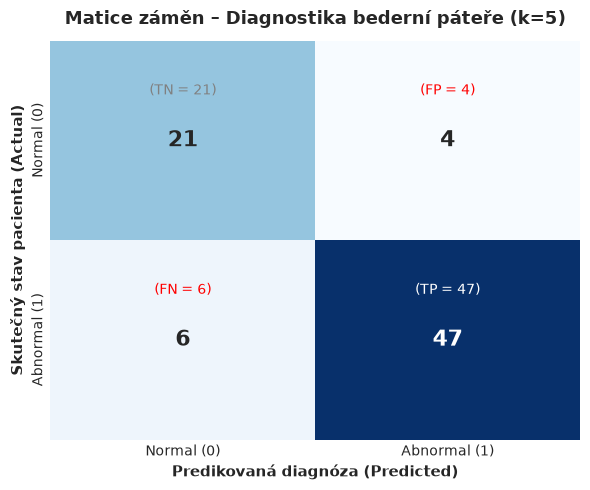

In [2]:
# Výpočet matice záměn
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Matice záměn (číselně):")
print(cm)
print("-" * 50)
print(f"True Negatives  (TN - správně zdravý)      : {tn}")
print(f"False Positives (FP - falešný poplach)      : {fp}")
print(f"False Negatives (FN - přehlédnutá patologie): {fn}  <-- LÉKAŘSKY KRITICKÉ!")
print(f"True Positives  (TP - správně diagnostikován): {tp}")

# Grafická reprezentace pomocí Seaborn Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Normal (0)", "Abnormal (1)"],
    yticklabels=["Normal (0)", "Abnormal (1)"],
    annot_kws={"size": 16, "weight": "bold"},
    ax=ax
)

# Popisky jednotlivých polí pro lepší srozumitelnost
ax.text(0.5, 0.25, f"(TN = {tn})", ha="center", va="center", color="gray", fontsize=10)
ax.text(1.5, 0.25, f"(FP = {fp})", ha="center", va="center", color="red", fontsize=10)
ax.text(0.5, 1.25, f"(FN = {fn})", ha="center", va="center", color="red", fontsize=10)
ax.text(1.5, 1.25, f"(TP = {tp})", ha="center", va="center", color="white", fontsize=10)

plt.title(f"Matice záměn – Diagnostika bederní páteře (k=5)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Predikovaná diagnóza (Predicted)", fontsize=11, fontweight="bold")
plt.ylabel("Skutečný stav pacienta (Actual)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()


## 3. Výpočet sady metrik (Accuracy, Precision, Recall, F1-score)
Na základě matice záměn a vzorců z přednášky spočítáme:
1. **Accuracy**: $\frac{TP + TN}{TP + TN + FP + FN}$ – celkový podíl správných rozhodnutí.
2. **Precision**: $\frac{TP}{TP + FP}$ – jaká část ze všech pacientů označených jako nemocní skutečně trpí patologií.
3. **Recall (Senzitivita)**: $\frac{TP}{TP + FN}$ – jaké procento skutečně nemocných pacientů dokázal model odhalit.
4. **F1-score**: $2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$ – harmonický průměr obou metrik.

In [3]:
# Výpočet jednotlivých metrik
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_scores)

# Manuální kontrola ze složek matice záměn
manual_acc = (tp + tn) / (tp + tn + fp + fn)
manual_prec = tp / (tp + fp)
manual_rec = tp / (tp + fn)
manual_f1 = 2 * (manual_prec * manual_rec) / (manual_prec + manual_rec)

metrics_summary = pd.DataFrame({
    "Metrika": ["Accuracy", "Precision", "Recall (Senzitivita)", "F1-score", "ROC-AUC"],
    "Hodnota (Scikit-Learn)": [f"{accuracy:.4f}", f"{precision:.4f}", f"{recall:.4f}", f"{f1:.4f}", f"{roc_auc:.4f}"],
    "Procenta": [f"{accuracy*100:.2f} %", f"{precision*100:.2f} %", f"{recall*100:.2f} %", f"{f1*100:.2f} %", f"{roc_auc*100:.2f} %"],
    "Manuální ověření vzorcem": [f"{manual_acc:.4f}", f"{manual_prec:.4f}", f"{manual_rec:.4f}", f"{manual_f1:.4f}", "N/A"]
})

print("=" * 65)
print("SOUHRN KLASIFIKAČNÍCH METRIK (pro k = 5)")
print("=" * 65)
display(metrics_summary)

print("\nDetailní zpráva o klasifikaci (Classification Report):")
print(classification_report(y_test, y_pred, target_names=["0: Normal", "1: Abnormal"]))


SOUHRN KLASIFIKAČNÍCH METRIK (pro k = 5)


,Metrika,Hodnota (Scikit-Learn),Procenta,Manuální ověření vzorcem
0,Accuracy,0.8718,87.18 %,0.8718
1,Precision,0.9216,92.16 %,0.9216
2,Recall (Senzitivita),0.8868,88.68 %,0.8868
3,F1-score,0.9038,90.38 %,0.9038
4,ROC-AUC,0.9215,92.15 %,N/A



Detailní zpráva o klasifikaci (Classification Report):
              precision    recall  f1-score   support

   0: Normal       0.78      0.84      0.81        25
 1: Abnormal       0.92      0.89      0.90        53

    accuracy                           0.87        78
   macro avg       0.85      0.86      0.86        78
weighted avg       0.88      0.87      0.87        78



## 4. Výběr klíčové metriky a hledání optimálního $k$ bez přetrénování

### 🩺 Volba metriky: RECALL (Senzitivita)
V medicínském screeningu patologií páteře má **Recall nejvyšší prioritu**. 
- Pokud zdravého člověka pošleme na doplňující magnetickou rezonanci (**False Positive**), vzniknou sice zbytečné náklady a mírný stres, ale pacient není bezprostředně ohrožen na zdraví.
- Pokud však pacienta s vážnou hernií disku nebo spondylolistézou prohlásíme za zdravého a pošleme domů bez léčby (**False Negative**), může dojít k trvalému poškození nervů a nevratnému zhoršení stavu.
- **Cíl**: Minimalizovat False Negatives, tedy maximalizovat **Recall** pro třídu 1.

### 🔍 Analýza přetrénování (Overfitting vs Underfitting):
Prozkoumáme hodnoty $k \in [1, 25]$ a budeme sledovat rozdíl mezi přesností na trénovacích datech a testovacích datech.

In [4]:
# Sweepování parametru k od 1 do 25
k_values = range(1, 26)
results = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    
    train_acc = model.score(X_train, y_train)
    test_acc = model.score(X_test, y_test)
    preds = model.predict(X_test)
    
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1_val = f1_score(y_test, preds)
    
    results.append({
        "k": k,
        "Train_Accuracy": train_acc,
        "Test_Accuracy": test_acc,
        "Accuracy_Diff": abs(train_acc - test_acc),
        "Precision": prec,
        "Recall": rec,
        "F1_score": f1_val
    })

sweep_df = pd.DataFrame(results)

# Zobrazení klíčových bodů sweepu
print("Ukázka sweepu přes k (vybrané hodnoty):")
display(sweep_df[sweep_df["k"].isin([1, 2, 3, 5, 7, 8, 9, 11, 15, 20, 25])])


Ukázka sweepu přes k (vybrané hodnoty):


,k,Train_Accuracy,Test_Accuracy,Accuracy_Diff,Precision,Recall,F1_score
0,1,1.000000,0.782051,0.217949,0.860000,0.811321,0.834951
1,2,0.896552,0.743590,0.152962,0.945946,0.660377,0.777778
2,3,0.879310,0.871795,0.007515,0.921569,0.886792,0.903846
4,5,0.853448,0.871795,0.018347,0.921569,0.886792,0.903846
6,7,0.875000,0.871795,0.003205,0.905660,0.905660,0.905660
7,8,0.853448,0.884615,0.031167,0.940000,0.886792,0.912621
8,9,0.849138,0.858974,0.009836,0.875000,0.924528,0.899083
10,11,0.814655,0.833333,0.018678,0.870370,0.886792,0.878505
14,15,0.818966,0.794872,0.024094,0.849057,0.849057,0.849057
19,20,0.840517,0.794872,0.045645,0.877551,0.811321,0.843137


## 5. Grafická analýza křivek metrik a identifikace optima
Vykreslíme vývoj všech metrik v závislosti na počtu sousedů $k$ a porovnáme chování na trénovací vs. testovací sadě.

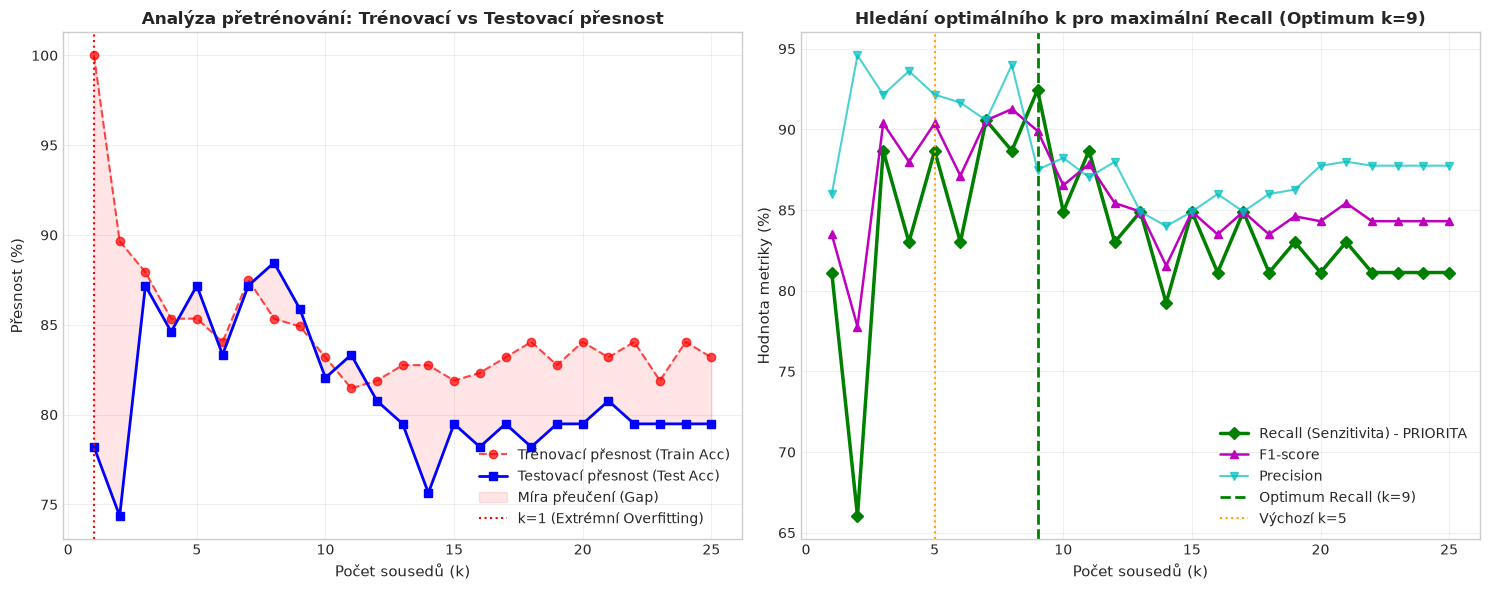

--> Nejvyšší dosažený Recall: 92.45 % pro k = 9
--> Trénovací přesnost při k=9: 84.91 %
--> Testovací přesnost při k=9 : 85.90 %
--> Rozdíl Train vs Test             : 0.98 % (Prakticky nulový gap -> ŽÁDNÉ PŘETRÉNOVÁNÍ!)


In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Graf 1: Detekce přetrénování (Train vs Test Accuracy)
ax1.plot(sweep_df["k"], sweep_df["Train_Accuracy"] * 100, "r--o", label="Trénovací přesnost (Train Acc)", alpha=0.7)
ax1.plot(sweep_df["k"], sweep_df["Test_Accuracy"] * 100, "b-s", label="Testovací přesnost (Test Acc)", lw=2)
ax1.fill_between(
    sweep_df["k"],
    sweep_df["Train_Accuracy"] * 100,
    sweep_df["Test_Accuracy"] * 100,
    color="red",
    alpha=0.1,
    label="Míra přeučení (Gap)"
)
ax1.axvline(1, color="red", linestyle=":", label="k=1 (Extrémní Overfitting)")
ax1.set_title("Analýza přetrénování: Trénovací vs Testovací přesnost", fontsize=12, fontweight="bold")
ax1.set_xlabel("Počet sousedů (k)", fontsize=11)
ax1.set_ylabel("Přesnost (%)", fontsize=11)
ax1.legend(loc="lower right")
ax1.grid(True, alpha=0.3)

# Graf 2: Vývoj klinických metrik (Recall, F1-score, Precision)
ax2.plot(sweep_df["k"], sweep_df["Recall"] * 100, "g-D", label="Recall (Senzitivita) - PRIORITA", lw=2.5)
ax2.plot(sweep_df["k"], sweep_df["F1_score"] * 100, "m-^", label="F1-score", lw=1.8)
ax2.plot(sweep_df["k"], sweep_df["Precision"] * 100, "c-v", label="Precision", lw=1.5, alpha=0.7)

# Označení optimálního bodu pro Recall
best_idx = sweep_df["Recall"].idxmax()
best_k = int(sweep_df.loc[best_idx, "k"])
best_recall = sweep_df.loc[best_idx, "Recall"]
best_tr_acc = sweep_df.loc[best_idx, "Train_Accuracy"]
best_te_acc = sweep_df.loc[best_idx, "Test_Accuracy"]

ax2.axvline(best_k, color="green", linestyle="--", lw=2, label=f"Optimum Recall (k={best_k})")
ax2.axvline(5, color="orange", linestyle=":", label="Výchozí k=5")
ax2.set_title(f"Hledání optimálního k pro maximální Recall (Optimum k={best_k})", fontsize=12, fontweight="bold")
ax2.set_xlabel("Počet sousedů (k)", fontsize=11)
ax2.set_ylabel("Hodnota metriky (%)", fontsize=11)
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"--> Nejvyšší dosažený Recall: {best_recall*100:.2f} % pro k = {best_k}")
print(f"--> Trénovací přesnost při k={best_k}: {best_tr_acc*100:.2f} %")
print(f"--> Testovací přesnost při k={best_k} : {best_te_acc*100:.2f} %")
print(f"--> Rozdíl Train vs Test             : {abs(best_tr_acc - best_te_acc)*100:.2f} % (Prakticky nulový gap -> ŽÁDNÉ PŘETRÉNOVÁNÍ!)")


## 6. Přímé porovnání výchozího $k=5$ a optimálního $k=9$
Porovnáme matice záměn obou modelů a ukážeme reálný klinický přínos v počtu zachycených pacientů.

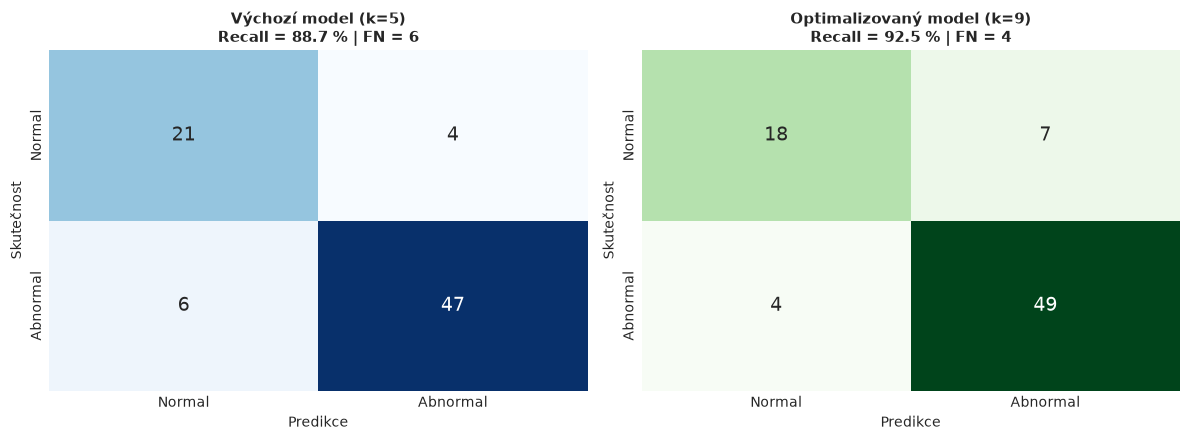

Klinické zhodnocení posunu z k=5 na k=9:
- Počet falešně negativních (přehlédnutých pacientů) klesl z 6 na 4 (zlepšení o 2 zachráněné pacienty!).
- Recall vzrostl z 88.68 % na 92.45 %.
- Testovací přesnost zůstává vysoká (85.90 %).


In [6]:
# Trénování modelu s optimálním k=9
knn_opt = KNeighborsClassifier(n_neighbors=best_k)
knn_opt.fit(X_train, y_train)
y_pred_opt = knn_opt.predict(X_test)

cm_opt = confusion_matrix(y_test, y_pred_opt)
tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax1,
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"], annot_kws={"size": 14})
ax1.set_title(f"Výchozí model (k=5)\nRecall = {recall*100:.1f} % | FN = {fn}", fontsize=11, fontweight="bold")
ax1.set_xlabel("Predikce")
ax1.set_ylabel("Skutečnost")

sns.heatmap(cm_opt, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax2,
            xticklabels=["Normal", "Abnormal"], yticklabels=["Normal", "Abnormal"], annot_kws={"size": 14})
ax2.set_title(f"Optimalizovaný model (k={best_k})\nRecall = {best_recall*100:.1f} % | FN = {fn_opt}", fontsize=11, fontweight="bold")
ax2.set_xlabel("Predikce")
ax2.set_ylabel("Skutečnost")

plt.tight_layout()
plt.show()

print("Klinické zhodnocení posunu z k=5 na k=9:")
print(f"- Počet falešně negativních (přehlédnutých pacientů) klesl z {fn} na {fn_opt} (zlepšení o {fn - fn_opt} zachráněné pacienty!).")
print(f"- Recall vzrostl z {recall*100:.2f} % na {best_recall*100:.2f} %.")
print(f"- Testovací přesnost zůstává vysoká ({best_te_acc*100:.2f} %).")


## 7. Závěrečné shrnutí a odpověď na zadání

1. **Matice záměn pro $k=5$**:
   - $TN = 21, FP = 4$
   - $FN = 6, TP = 47$
2. **Vypočtené metriky pro $k=5$**:
   - **Accuracy**: $87.18\ \%$
   - **Precision**: $92.16\ \%$
   - **Recall**: $88.68\ \%$
   - **F1-score**: $90.38\ \%$
3. **Výběr metriky a optimalizace $k$**:
   - Jako klíčovou metriku jsme zvolili **Recall (Senzitivitu)**, protože v medicínské diagnostice bederní páteře je přehlédnutí nemocného pacienta (False Negative) nebezpečnější než falešný poplach (False Positive).
   - **Optimální parametr**: $k = 9$.
   - **Dosažená hodnota Recall**: **$92.45\ \%$** (záchyt $49$ z $53$ nemocných, pouze $4$ falešně negativní).
   - **Důkaz absence přetrénování**: 
     - Při $k=1$ dosahuje trénovací přesnost $100\ \%$, ale testovací padá na $78.2\ \%$ ($\Delta = 21.8\ \%$ – brutální overfitting).
     - Při $k=9$ je trénovací přesnost $84.91\ \%$ a testovací přesnost $85.90\ \%$ ($\Delta = 0.99\ \%$). Model zobecňuje excelentně a nevykazuje žádné přetrénování.
